In [ ]:
from typing import TypedDict, Annotated, Optional
from langgraph.graph import add_messages, StateGraph, END
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.checkpoint.memory import MemorySaver
from uuid import uuid4
import json

load_dotenv()

model = ChatGroq(
model="llama-3.1-8b-instant",
temperature=0
)

# model = ChatOpenAI(model="gpt-4o")

AIMessage(content="Here's one:\n\nWhy did the cat join a band?\n\nBecause it wanted to be the purr-cussionist.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 42, 'total_tokens': 67, 'completion_time': 0.032218951, 'completion_tokens_details': None, 'prompt_time': 0.00295216, 'prompt_tokens_details': None, 'queue_time': 0.006257938, 'total_time': 0.035171111}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd42f-37e3-77c0-9d3e-1eac36c36b60-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 25, 'total_tokens': 67})

In [8]:
search_tool = TavilySearchResults(max_results=4)
# response = model.invoke("give me jok about the cat")
# response
tools = [search_tool]

memory = MemorySaver()

In [9]:
llm_with_tools = model.bind_tools(tools=tools)

In [10]:
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage

class State(TypedDict):
    messages: Annotated[list, add_messages]

async def model(state: State):
    result = await llm_with_tools.ainvoke(state["messages"])
    return {
        "messages": [result], 
    }

async def tools_router(state: State):
    last_message = state["messages"][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else: 
        return END
    
async def tool_node(state):
    """Custom tool node that handles tool calls from the LLM."""
    # Get the tool calls from the last message
    tool_calls = state["messages"][-1].tool_calls
    
    # Initialize list to store tool messages
    tool_messages = []
    
    # Process each tool call
    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]
        
        # Handle the search tool
        if tool_name == "tavily_search_results_json":
            # Execute the search tool with the provided arguments
            search_results = await search_tool.ainvoke(tool_args)
            
            # Create a ToolMessage for this result
            tool_message = ToolMessage(
                content=str(search_results),
                tool_call_id=tool_id,
                name=tool_name
            )
            
            tool_messages.append(tool_message)
    
    # Add the tool messages to the state
    return {"messages": tool_messages}

graph_builder = StateGraph(State)

graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tool_node)
graph_builder.set_entry_point("model")

graph_builder.add_conditional_edges("model", tools_router)
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)


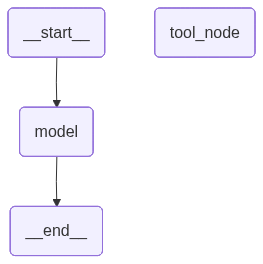

In [15]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
      
        )
    )
)

In [14]:
config = {
    "configurable": {
        "thread_id": 5
    }
}

response = await graph.ainvoke({
    "messages": [HumanMessage(content="When is the next spaceX launch?")], 
}, config=config)

response

{'messages': [HumanMessage(content='When is the next spaceX launch?', additional_kwargs={}, response_metadata={}, id='e4545749-b349-4402-accd-5ef2634b49b6'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '2mm39dy79', 'function': {'arguments': '{"query":"SpaceX next launch date"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 286, 'total_tokens': 308, 'completion_time': 0.0340546, 'completion_tokens_details': None, 'prompt_time': 0.01965165, 'prompt_tokens_details': None, 'queue_time': 0.00531911, 'total_time': 0.05370625}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dd447-3ff8-7081-bbe2-1d8e9737ff55-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'SpaceX next launch date'}, 'id': '2mm39dy79', 'type':

In [16]:
config = {
    "configurable": {
        "thread_id": 8
    }
}

# Use async for to iterate over the async generator
async for event in graph.astream_events({
    "messages": [HumanMessage(content="When is the next spacex launch?")],
}, config=config, version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='When is the next spacex launch?', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019dd449-fa89-7e82-9ee8-523b658fb8c9', 'metadata': {'thread_id': 8, 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='When is the next spacex launch?', additional_kwargs={}, response_metadata={}, id='fab606bb-587a-433c-94aa-c55f49620f91')]}}, 'name': 'model', 'tags': ['graph:step:1'], 'run_id': '019dd449-fa93-75c2-b01c-8425e099e955', 'metadata': {'thread_id': 8, 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:716e36ae-e8a8-4278-412f-5a702dc5c230'}, 'parent_ids': ['019dd449-fa89-7e82-9ee8-523b658fb8c9']}
{'event': 'on_chain_start', 'data': {'input': 